# Phase 1C — GRU & 1D-CNN Architectures

| Paramètre | Valeur |
|-----------|---------------------------|
| Window size | 30 |
| Features | 14 |
| Batch size | 256 |
| Learning rate | 0.001 |
| Dropout | 0.2 |
| Optimizer | Adam |
| Loss | MSE |
| Max epochs | 100 |
| Early stopping patience | 10 |
| Random seed | 42 |

---
### Table des matières
1. Setup & Chargement
2. Train/Val Split
3. Architecture GRU
4. Architecture 1D-CNN
5. NASA Scoring Function


## 1. Setup & Chargement

In [ ]:
import numpy as np
import pandas as pd
import json, os, joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    GRU, Conv1D, Dense, Dropout,
    GlobalAveragePooling1D, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam


SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

print(f'TensorFlow : {tf.__version__}')
print(f'GPU dispo  : {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow : 2.19.0
GPU dispo  : True


In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
BASE_DIR  = '/content/drive/MyDrive/industrial-ai-platform'
PROC_DIR  = f'{BASE_DIR}/phase_preprocessing'
MODEL_DIR = f'{BASE_DIR}/phase1C_gru_cnn'
CONFIG_PATH = f'{BASE_DIR}/feature_config.json'

os.makedirs(MODEL_DIR, exist_ok=True)


X_train_full = np.load(f'{PROC_DIR}/X_train.npy')
y_train_full = np.load(f'{PROC_DIR}/y_train.npy')
X_test       = np.load(f'{PROC_DIR}/X_test.npy')
y_test       = np.load(f'{PROC_DIR}/y_test.npy')

with open(CONFIG_PATH) as f:
    config = json.load(f)

WINDOW_SIZE = config['window_size']   # 30
N_FEATURES  = config['n_features']    # 14
RUL_CAP     = config['rul_cap']       # 125

print(f'X_train_full : {X_train_full.shape}')
print(f'X_test       : {X_test.shape}')
print(f'Window={WINDOW_SIZE}  Features={N_FEATURES}  RUL cap={RUL_CAP}')

X_train_full : (17731, 30, 14)
X_test       : (100, 30, 14)
Window=30  Features=14  RUL cap=125


## 2. Train/Val Split

In [ ]:

unit_ids_per_seq = np.load(f'{BASE_DIR}/phase_preprocessing/unit_ids_train.npy')

# Split 80/20
all_units = np.unique(unit_ids_per_seq)
np.random.seed(SEED)
np.random.shuffle(all_units)

n_val       = int(len(all_units) * 0.20)
val_units   = set(all_units[:n_val])
train_units = set(all_units[n_val:])

assert len(val_units & train_units) == 0, '🚨 Data leakage !'

train_mask = np.array([uid in train_units for uid in unit_ids_per_seq])
val_mask   = ~train_mask

X_train, y_train = X_train_full[train_mask], y_train_full[train_mask]
X_val,   y_val   = X_train_full[val_mask],   y_train_full[val_mask]

print(f'Moteurs train : {len(train_units)}  |  val : {len(val_units)}')
print(f'Séquences train : {X_train.shape[0]:,}  |  val : {X_val.shape[0]:,}')
print('✅ Split identique au LSTM — comparaison équitable garantie')

Moteurs train : 80  |  val : 20
Séquences train : 14,241  |  val : 3,490
✅ Split identique au LSTM — comparaison équitable garantie


## 3. Architecture GRU

In [ ]:
def build_gru(window_size, n_features,
              gru1_units=128, gru2_units=64,
              dropout_rate=0.2, dense_units=32,
              learning_rate=1e-3):
    """
    Architecture GRU

    """
    model = Sequential([
        GRU(gru1_units,
            input_shape=(window_size, n_features),
            return_sequences=True,
            name='gru_1'),
        Dropout(dropout_rate, name='dropout_1'),

        GRU(gru2_units,
            return_sequences=False,
            name='gru_2'),
        Dropout(dropout_rate, name='dropout_2'),

        Dense(dense_units, activation='relu', name='dense_1'),
        Dense(1, activation='linear', name='output')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model


tf.random.set_seed(SEED)
np.random.seed(SEED)
gru_model = build_gru(WINDOW_SIZE, N_FEATURES)
gru_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_1 (GRU)                     │ (None, 30, 128)        │        55,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_2 (GRU)                     │ (None, 64)             │        37,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,657 (369.75 KB)

 Trainable params: 94,657 (369.75 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Callbacks
gru_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint(f'{MODEL_DIR}/gru_best.keras',
                    monitor='val_loss', save_best_only=True, verbose=0)
]

print(' Entraînement GRU...')
gru_history = gru_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    callbacks=gru_callbacks,
    verbose=1
)

gru_model.save(f'{MODEL_DIR}/gru_final.keras')
print(f'\n GRU terminé — {len(gru_history.history["loss"])} epochs')

🚀 Entraînement GRU...
Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - loss: 6650.0869 - mae: 70.7099 - val_loss: 5062.1084 - val_mae: 60.5918 - learning_rate: 0.0010
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 3962.9939 - mae: 53.6012 - val_loss: 2782.8105 - val_mae: 45.5457 - learning_rate: 0.0010
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - loss: 2262.6858 - mae: 41.8695 - val_loss: 1844.3954 - val_mae: 38.4317 - learning_rate: 0.0010
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 1810.7101 - mae: 37.9648 - val_loss: 1744.1592 - val_mae: 37.1401 - learning_rate: 0.0010
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1772.4408 - mae: 37.3610 - val_loss: 1743.6388 - val_mae: 37.0263 - learning_rate: 0.0010
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1769.8724 - mae: 37.3655 - val_loss: 1677.4901 - val_mae: 36.4612 - learning_rate: 0.0010
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - loss: 1425.1862 - mae: 3

## 4. Architecture 1D-CNN

In [ ]:
def build_cnn1d(window_size, n_features,
                filters1=64, filters2=32,
                kernel_size=3, dropout_rate=0.2,
                dense_units=32, learning_rate=1e-3):
    """
    Architecture 1D-CNN :
    2x Conv1D → GlobalAveragePooling1D → Dense → Output
    Les filtres Conv1D détectent des patterns locaux dans la fenêtre temporelle.
    """
    model = Sequential([
        # Couche Conv1D 1
        Conv1D(filters=filters1,
               kernel_size=kernel_size,
               activation='relu',
               padding='same',
               input_shape=(window_size, n_features),
               name='conv1d_1'),
        Dropout(dropout_rate, name='dropout_1'),

        # Couche Conv1D 2
        Conv1D(filters=filters2,
               kernel_size=kernel_size,
               activation='relu',
               padding='same',
               name='conv1d_2'),
        Dropout(dropout_rate, name='dropout_2'),

        # Global Average Pooling — réduit (window, filters) → (filters,)
        GlobalAveragePooling1D(name='global_avg_pool'),

        Dense(dense_units, activation='relu', name='dense_1'),
        Dense(1, activation='linear', name='output')
    ])

    model.compile(
        optimizer=Adam(learning_rate=learning_rate),
        loss='mse',
        metrics=['mae']
    )
    return model


tf.random.set_seed(SEED)
np.random.seed(SEED)
cnn_model = build_cnn1d(WINDOW_SIZE, N_FEATURES)
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_1 (Conv1D)               │ (None, 30, 64)         │         2,752 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 30, 32)         │         6,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_avg_pool                 │ (None, 32)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,017 (39.13 KB)

 Trainable params: 10,017 (39.13 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
cnn_callbacks = [
    EarlyStopping(monitor='val_loss', patience=10,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=5, min_lr=1e-6, verbose=1),
    ModelCheckpoint(f'{MODEL_DIR}/cnn_best.keras',
                    monitor='val_loss', save_best_only=True, verbose=0)
]

print('🚀 Entraînement 1D-CNN...')
cnn_history = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100,
    batch_size=256,
    callbacks=cnn_callbacks,
    verbose=1
)

cnn_model.save(f'{MODEL_DIR}/cnn_final.keras')
print(f'\n✅ CNN terminé — {len(cnn_history.history["loss"])} epochs')

🚀 Entraînement 1D-CNN...
Epoch 1/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 10s 91ms/step - loss: 6844.6343 - mae: 71.8655 - val_loss: 2709.4785 - val_mae: 45.6708 - learning_rate: 0.0010
Epoch 2/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 2055.1428 - mae: 39.8673 - val_loss: 1734.8044 - val_mae: 36.8709 - learning_rate: 0.0010
Epoch 3/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1434.7870 - mae: 33.6110 - val_loss: 949.0277 - val_mae: 27.3175 - learning_rate: 0.0010
Epoch 4/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 783.5499 - mae: 23.7067 - val_loss: 542.5890 - val_mae: 18.0207 - learning_rate: 0.0010
Epoch 5/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 621.6971 - mae: 20.2507 - val_loss: 483.2525 - val_mae: 16.7752 - learning_rate: 0.0010
Epoch 6/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 579.9603 - mae: 19.5106 - val_loss: 451.0435 - val_mae: 16.3359 - learning_rate: 0.0010
Epoch 7/100
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 558.1168 - mae: 19.0815 - v

## 5. NASA Scoring Function

In [ ]:
def nasa_score(y_true, y_pred):
    """
    Fonction de scoring NASA — asymétrique :
    - Prédiction tardive (d > 0) : pénalité plus forte → dangereux
    - Prédiction précoce (d < 0) : pénalité plus faible → gaspillage mais sûr
    Score plus bas = meilleur.
    """
    d = np.array(y_pred) - np.array(y_true)
    scores = np.where(d < 0, np.exp(-d / 13) - 1, np.exp(d / 10) - 1)
    return float(np.sum(scores))


def compute_all_metrics(y_true, y_pred, model_name=''):
    rmse  = np.sqrt(mean_squared_error(y_true, y_pred))
    mae   = mean_absolute_error(y_true, y_pred)
    r2    = r2_score(y_true, y_pred)
    nasa  = nasa_score(y_true, y_pred)
    print(f'[{model_name}]  RMSE:{rmse:.3f}  MAE:{mae:.3f}  R²:{r2:.4f}  NASA:{nasa:.1f}')
    return {'model': model_name, 'rmse': rmse, 'mae': mae, 'r2': r2, 'nasa': nasa}

print(' NASA scoring function définie')

 NASA scoring function définie


In [ ]:
# Prédictions GRU
y_val_pred_gru  = gru_model.predict(X_val,  verbose=0).flatten()
y_test_pred_gru = gru_model.predict(X_test, verbose=0).flatten()

# Prédictions CNN
y_val_pred_cnn  = cnn_model.predict(X_val,  verbose=0).flatten()
y_test_pred_cnn = cnn_model.predict(X_test, verbose=0).flatten()

print('=' * 65)
print('VALIDATION SET')
metrics_gru_val = compute_all_metrics(y_val,  y_val_pred_gru,  'GRU ')
metrics_cnn_val = compute_all_metrics(y_val,  y_val_pred_cnn,  'CNN ')
print('\nTEST SET')
metrics_gru_test = compute_all_metrics(y_test, y_test_pred_gru, 'GRU ')
metrics_cnn_test = compute_all_metrics(y_test, y_test_pred_cnn, 'CNN ')
print('=' * 65)

VALIDATION SET
[GRU ]  RMSE:11.622  MAE:8.177  R²:0.9225  NASA:7195.7
[CNN ]  RMSE:15.581  MAE:11.834  R²:0.8607  NASA:18510.4

TEST SET
[GRU ]  RMSE:13.586  MAE:10.008  R²:0.8851  NASA:327.6
[CNN ]  RMSE:16.607  MAE:12.333  R²:0.8283  NASA:613.1


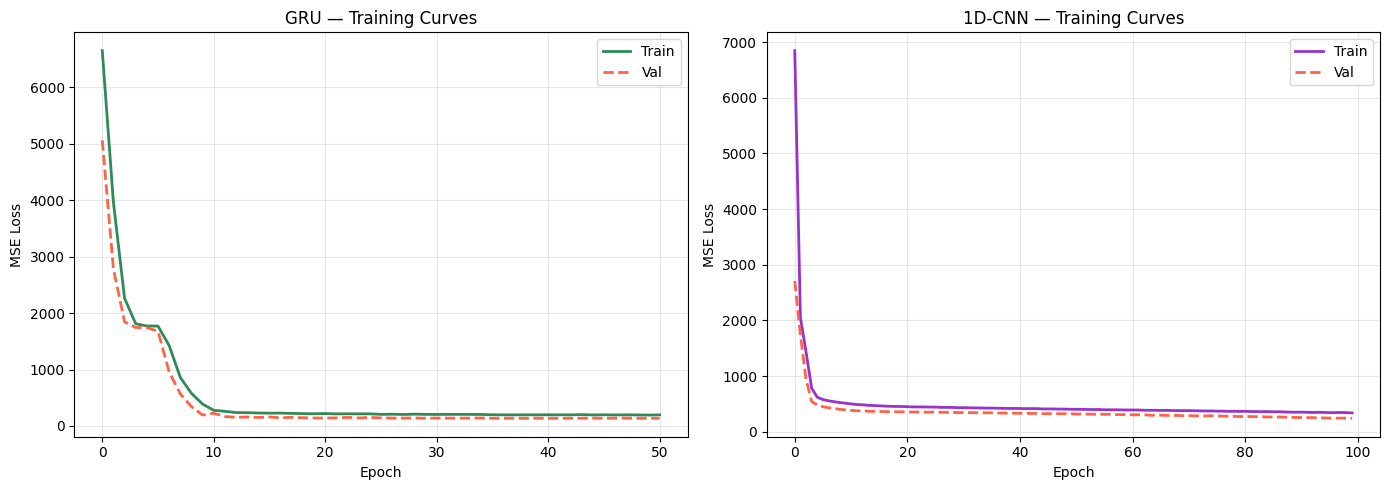

In [ ]:
# Courbes de loss GRU vs CNN
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, history, name, color in [
    (axes[0], gru_history, 'GRU',    'seagreen'),
    (axes[1], cnn_history, '1D-CNN', 'darkorchid')
]:
    ax.plot(history.history['loss'],     color=color,  label='Train', linewidth=2)
    ax.plot(history.history['val_loss'], color='tomato', label='Val', linewidth=2, linestyle='--')
    ax.set_title(f'{name} — Training Curves', fontsize=12)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{MODEL_DIR}/training_curves.png', bbox_inches='tight', dpi=110)
plt.show()